<a href="https://colab.research.google.com/github/kristinaswan/pet_projects/blob/main/cafe_purchase_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Анализ кафе для покупки (локация, метро, конкуренты)**

Задача:

Владелец сети ресторанов хочет купить кафе. На выбор есть 5 вариантов приблизительно по одной цене, нужно предоставить информацию по каждому кафе по описанным ниже критериям.

Критерии:

1. Точка должна находится внутри МКАД;
2. Чем больше в радиусе 600 метров станций метро, тем больше потенциальных покупателей, а значит место привлекательнее;
3. Чем меньше конкурентов находится на расстоянии 100 м по прямой, но чем больше на расстоянии 1 км, тем лучше.
    
Результат:

1. Датасет из 5 строк со следующий набором полей:

    1. Global_id кафе;
    2. Флаг, находится ли кафе в границах МКАД;
    3. Количество станций метро (уникальных названий, а не выходов) в радиусе 600 метров;
    4. Количество кафе-конкурентов в 100 метрах;
    5. Количество кафе-конкуретнов в 1 км.

2. Сделать вывод, какая точка или точки наиболее привлекательны для открытия кафе и почему.


Шаги:

1. Загрузить датасеты, перевести их если нужно в geodataframe, определить базовую crs;
2. Убедиться, что в каждом датасете используется пространственный индекс;
3. Проверить находятся ли точки внутри МКАД и сохранить в колонку 'flag_in_mkad';
4. Перевести датасеты в utm, построить буфер 600 м вокруг кафе, сделать буфер геометрией датасета. Сделать spatial join таблицы с кафе с таблицей станций метро (подумайте какой должен быть тип пересечения). Сохранить результат в отдельной таблице;
5. Сгруппировать по global_id кафе и посчитать количество уникальных названий станций метро в его радиусе;
6. Сцепить по global_id (функция merge), сохраненный датасет с датасетом, полученным на шаге 5. Убедиться, что количество строк не изменилось (5 кафе - 5 строк);
7. Перевести датасеты cafe2buy и cafe_competitors в utm;
8. Построить буферы 100 и 1000 м и сцепить слева с таблицей gdf_cafe_competitors;
9. Сгруппировать по global_id кофейни из cofe2buy, чтобы посчитать количество конкурентов в 100 и 1000 метрах. Убедиться, чтодублей нет и кафе для покупки не учитывается в подсчете числа конкурентов;
10. Вывести результат (5 кафе - 5 строк) и сделать вывод, какое кафе надо рекомендовать.

In [4]:
# Импортируем необходимые библиотеки
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import math
from pyproj import CRS, Transformer
import pandas as pd

 1. Загрузить датасеты, перевести их если нужно в geodataframe, определить базовую crs

Входные данные

In [5]:
# Прочитаем файл cafe2buy.geojson и сохраним его в переменной gdf_cafe2buy
gdf_cafe2buy = gpd.read_file(r"cafe2buy.geojson")

In [6]:
# Выведем первые пять строк датафрейма
gdf_cafe2buy.head()

,global_id,Caption,geometry
0,637429252,coffee,POINT (37.55587 55.93647)
1,878847582,coffee,POINT (37.50745 55.75693)
2,878848499,coffee,POINT (37.29767 55.48605)
3,930779009,coffee,POINT (37.52775 55.79018)
4,1026816942,coffee,POINT (37.76777 55.71054)


In [7]:
# Прочитаем файл cafe_msk.geojson и сохраним его в переменной gdf_cafe_competitors
gdf_cafe_competitors = gpd.read_file(r"cafe_msk.geojson")

In [8]:
# Выведем первые пять строк датафрейма
gdf_cafe_competitors.head()

,global_id,Caption,geometry
0,637376221,coffee,POINT (37.71457 55.879)
1,637376331,coffee,POINT (37.67331 55.73824)
2,637376349,coffee,POINT (37.66965 55.73551)
3,637376403,coffee,POINT (37.57231 55.90409)
4,637376481,coffee,POINT (37.59813 55.74739)


In [9]:
# Прочитаем файл gdf_metro.geojson и сохраним его в переменной gdf_metro
gdf_metro = gpd.read_file("gdf_metro.geojson")

In [10]:
# Выведем первые пять строк датафрейма
gdf_metro.head()

,Unnamed: 0,global_id,Caption,NameOfStation,geometry
0,0,1773539,metro,Китай-город,POINT (37.63168 55.75732)
1,1,1773540,metro,Китай-город,POINT (37.6312 55.75686)
2,2,1773541,metro,Китай-город,POINT (37.63195 55.75724)
3,3,1773542,metro,Китай-город,POINT (37.63308 55.7531)
4,4,1773543,metro,Китай-город,POINT (37.63356 55.75307)


In [11]:
# В датасете gdf_metro сразу удалим ненужное поле 'Unnamed: 0'
gdf_metro = gdf_metro.drop('Unnamed: 0', axis=1)

In [12]:
# Снова выведем первые пять строк датафрейма
gdf_metro.head()

,global_id,Caption,NameOfStation,geometry
0,1773539,metro,Китай-город,POINT (37.63168 55.75732)
1,1773540,metro,Китай-город,POINT (37.6312 55.75686)
2,1773541,metro,Китай-город,POINT (37.63195 55.75724)
3,1773542,metro,Китай-город,POINT (37.63308 55.7531)
4,1773543,metro,Китай-город,POINT (37.63356 55.75307)


In [13]:
# Определим базовые crs
print(f"CRS gdf_cafe2buy: {gdf_cafe2buy.crs}")
print(f"CRS gdf_cafe_competitors: {gdf_cafe_competitors.crs}")
print(f"CRS gdf_metro: {gdf_metro.crs}")

CRS gdf_cafe2buy: EPSG:4326
CRS gdf_cafe_competitors: EPSG:4326
CRS gdf_metro: EPSG:4326


 2. Убедиться, что в каждом датасете используется пространственный индекс

In [14]:
gdf_cafe2buy.geometry

,geometry
0,POINT (37.55587 55.93647)
1,POINT (37.50745 55.75693)
2,POINT (37.29767 55.48605)
3,POINT (37.52775 55.79018)
4,POINT (37.76777 55.71054)


In [15]:
gdf_cafe_competitors.geometry.head()

,geometry
0,POINT (37.71457 55.879)
1,POINT (37.67331 55.73824)
2,POINT (37.66965 55.73551)
3,POINT (37.57231 55.90409)
4,POINT (37.59813 55.74739)


In [16]:
gdf_metro.geometry.head()

,geometry
0,POINT (37.63168 55.75732)
1,POINT (37.6312 55.75686)
2,POINT (37.63195 55.75724)
3,POINT (37.63308 55.7531)
4,POINT (37.63356 55.75307)


In [17]:
# Границы МКАДа
mkad_original = (
    [55.78000432402266, 37.84172564285271],
    [55.775874525970494, 37.8381207618713],
    [55.775626746008065, 37.83979446823122],
    [55.77446586811748, 37.84243326983639],
    [55.771974101091104, 37.84262672750849],
    [55.77114545193181, 37.84153238623039],
    [55.76722010265554, 37.841124690460184],
    [55.76654891107098, 37.84239076983644],
    [55.76258709833121, 37.842283558197025],
    [55.758073999993734, 37.8421759312134],
    [55.75381499999371, 37.84198330422974],
    [55.749277102484484, 37.8416827275085],
    [55.74794544108413, 37.84157576190186],
    [55.74525257875241, 37.83897929098507],
    [55.74404373042019, 37.83739676451868],
    [55.74298009816793, 37.838732481460525],
    [55.743060321833575, 37.841183997352545],
    [55.73938799999373, 37.84097476190185],
    [55.73570799999372, 37.84048155819702],
    [55.73228210777237, 37.840095812164286],
    [55.73080491981639, 37.83983814285274],
    [55.729799917464675, 37.83846476321406],
    [55.72919751082619, 37.83835745269769],
    [55.72859509486539, 37.838636380279524],
    [55.727705075632784, 37.8395161005249],
    [55.722727886185154, 37.83897964285276],
    [55.72034817326636, 37.83862557539366],
    [55.71944437307499, 37.83559735744853],
    [55.71831419154461, 37.835370708803126],
    [55.71765218986692, 37.83738169402022],
    [55.71691750159089, 37.83823396494291],
    [55.71547311301385, 37.838056931213345],
    [55.71221445615604, 37.836812846557606],
    [55.709331054395555, 37.83522525396725],
    [55.70953687463627, 37.83269301586908],
    [55.70903403789297, 37.829667367706236],
    [55.70552351822608, 37.83311126588435],
    [55.70041317726053, 37.83058993121339],
    [55.69883771404813, 37.82983872750851],
    [55.69718947487017, 37.82934501586913],
    [55.69504441658371, 37.828926414016685],
    [55.69287499999378, 37.82876530422971],
    [55.690759754047335, 37.82894754100031],
    [55.68951421135665, 37.827697554878185],
    [55.68965045405069, 37.82447346292115],
    [55.68322046195302, 37.83136543914793],
    [55.67814012759211, 37.833554015869154],
    [55.67295011628339, 37.83544184655761],
    [55.6672498719639, 37.837480388885474],
    [55.66316274139358, 37.838960677246064],
    [55.66046999999383, 37.83926093121332],
    [55.65869897264431, 37.839025050262435],
    [55.65794084879904, 37.83670784390257],
    [55.65694309303843, 37.835656529083245],
    [55.65689306460552, 37.83704060449217],
    [55.65550363526252, 37.83696819873806],
    [55.65487847246661, 37.83760389616388],
    [55.65356745541324, 37.83687972750851],
    [55.65155951234079, 37.83515216004943],
    [55.64979413590619, 37.83312418518067],
    [55.64640836412121, 37.82801726983639],
    [55.64164525405531, 37.820614174591],
    [55.6421883258084, 37.818908190475426],
    [55.64112490388471, 37.81717543386075],
    [55.63916106913107, 37.81690987037274],
    [55.637925371757085, 37.815099354492155],
    [55.633798276884455, 37.808769150787356],
    [55.62873670012244, 37.80100123544311],
    [55.62554336109055, 37.79598013491824],
    [55.62033499605651, 37.78634567724606],
    [55.618768681480326, 37.78334147619623],
    [55.619855533402706, 37.77746201055901],
    [55.61909966711279, 37.77527329626457],
    [55.618770300976294, 37.77801986242668],
    [55.617257701952106, 37.778212973541216],
    [55.61574504433011, 37.77784818518065],
    [55.61148576294007, 37.77016867724609],
    [55.60599579539028, 37.760191219573976],
    [55.60227892751446, 37.75338926983641],
    [55.59920577639331, 37.746329965606634],
    [55.59631430313617, 37.73939925396728],
    [55.5935318803559, 37.73273665739439],
    [55.59350760316188, 37.7299954450912],
    [55.59469840523759, 37.7268679946899],
    [55.59229549697373, 37.72626726983634],
    [55.59081598950582, 37.7262673598022],
    [55.5877595845419, 37.71897193121335],
    [55.58393177431724, 37.70871550793456],
    [55.580917323756644, 37.700497489410374],
    [55.57778089778455, 37.69204305026244],
    [55.57815154690915, 37.68544477378839],
    [55.57472945079756, 37.68391050793454],
    [55.57328235936491, 37.678803592590306],
    [55.57255251445782, 37.6743402539673],
    [55.57216388774464, 37.66813862698363],
    [55.57505691895805, 37.617927457672096],
    [55.5757737568051, 37.60443099999999],
    [55.57749105910326, 37.599683515869145],
    [55.57796291823627, 37.59754177842709],
    [55.57906686095235, 37.59625834786988],
    [55.57746616444403, 37.59501783265684],
    [55.57671634534502, 37.593090671936025],
    [55.577944600233785, 37.587018007904],
    [55.57982895000019, 37.578692203704804],
    [55.58116294118248, 37.57327546607398],
    [55.581550362779, 37.57385012109279],
    [55.5820107079112, 37.57399562266922],
    [55.58226289171689, 37.5735356072979],
    [55.582393529795155, 37.57290393054962],
    [55.581919415056234, 37.57037722355653],
    [55.584471614867844, 37.5592298306885],
    [55.58867650795186, 37.54189249206543],
    [55.59158133551745, 37.5297256269836],
    [55.59443656218868, 37.517837865081766],
    [55.59635625174229, 37.51200186508174],
    [55.59907823904434, 37.506808949737554],
    [55.6062944994944, 37.49820432275389],
    [55.60967103463367, 37.494406071441674],
    [55.61066689753365, 37.494760001358024],
    [55.61220931698269, 37.49397137107085],
    [55.613417718449064, 37.49016528606031],
    [55.61530616333343, 37.48773249206542],
    [55.622640129112334, 37.47921386508177],
    [55.62993723476164, 37.470652153442394],
    [55.6368075123157, 37.46273446298218],
    [55.64068225239439, 37.46350692265317],
    [55.640794546982576, 37.46050283203121],
    [55.64118904154646, 37.457627470916734],
    [55.64690488145138, 37.450718034393326],
    [55.65397824729769, 37.44239252645875],
    [55.66053543155961, 37.434587576721185],
    [55.661693766520735, 37.43582144975277],
    [55.662755031737014, 37.43576786245721],
    [55.664610641628116, 37.430982915344174],
    [55.66778515273695, 37.428547447097685],
    [55.668633314343566, 37.42945134592044],
    [55.66948145750025, 37.42859571562949],
    [55.670813882451405, 37.4262836402282],
    [55.6811141674414, 37.418709037048295],
    [55.68235377885389, 37.41922139651101],
    [55.68359335082235, 37.419218771842885],
    [55.684375235224735, 37.417196501327446],
    [55.68540557585352, 37.41607020370478],
    [55.68686637150793, 37.415640857147146],
    [55.68903015131686, 37.414632153442334],
    [55.690896881757396, 37.413344899475064],
    [55.69264232162232, 37.41171432275391],
    [55.69455101638112, 37.40948282275393],
    [55.69638690385348, 37.40703674603271],
    [55.70451821283731, 37.39607169577025],
    [55.70942491932811, 37.38952706878662],
    [55.71149057784176, 37.387778313491815],
    [55.71419814298992, 37.39049275399779],
    [55.7155489617061, 37.385557272491454],
    [55.71849856042102, 37.38388335714726],
    [55.7292763261685, 37.378368238098155],
    [55.730845879211614, 37.37763597123337],
    [55.73167906388319, 37.37890062088197],
    [55.734703664681774, 37.37750451918789],
    [55.734851959522246, 37.375610832015965],
    [55.74105626086403, 37.3723813571472],
    [55.746115620904355, 37.37014935714723],
    [55.750883999993725, 37.36944173016362],
    [55.76335905525834, 37.36975304365541],
    [55.76432079697595, 37.37244070571134],
    [55.76636979670426, 37.3724259757175],
    [55.76735417953104, 37.369922155757884],
    [55.76823419316575, 37.369892695770275],
    [55.782312184391266, 37.370214730163575],
    [55.78436801120489, 37.370493611114505],
    [55.78596427165359, 37.37120164550783],
    [55.7874378183096, 37.37284851456452],
    [55.7886695054807, 37.37608325135799],
    [55.78947647305964, 37.3764587460632],
    [55.79146512926804, 37.37530000265506],
    [55.79899647809345, 37.38235915344241],
    [55.80113596939471, 37.384344043655396],
    [55.80322699999366, 37.38594269577028],
    [55.804919036911976, 37.38711208598329],
    [55.806610999993666, 37.3880239841309],
    [55.81001864976979, 37.38928977249147],
    [55.81348641242801, 37.39038389947512],
    [55.81983538336746, 37.39235781481933],
    [55.82417822811877, 37.393709457672124],
    [55.82792275755836, 37.394685720901464],
    [55.830447148154136, 37.39557615344238],
    [55.83167107969975, 37.39844478226658],
    [55.83151823557964, 37.40019761214057],
    [55.83264967594742, 37.400398790382326],
    [55.83322180909622, 37.39659544313046],
    [55.83402792148566, 37.39667059524539],
    [55.83638877400216, 37.39682089947515],
    [55.83861656112751, 37.39643489154053],
    [55.84072348043264, 37.3955338994751],
    [55.84502158126453, 37.392680272491454],
    [55.84659117913199, 37.39241188227847],
    [55.84816071336481, 37.392529730163616],
    [55.85288092980303, 37.39486835714723],
    [55.859893456073635, 37.39873052645878],
    [55.86441833633205, 37.40272161111449],
    [55.867579567544375, 37.40697072750854],
    [55.868369880337, 37.410007082016016],
    [55.86920843741314, 37.4120992989502],
    [55.87055369615854, 37.412668021163924],
    [55.87170587948249, 37.41482461111453],
    [55.873183961039565, 37.41862266137694],
    [55.874879126654704, 37.42413732540892],
    [55.875614937236705, 37.4312182698669],
    [55.8762723478417, 37.43111093783558],
    [55.87706546369396, 37.43332105622856],
    [55.87790681284802, 37.43385747619623],
    [55.88027084462084, 37.441303050262405],
    [55.87942070143253, 37.44747234260555],
    [55.88072960917233, 37.44716141796871],
    [55.88121221323979, 37.44769797085568],
    [55.882080694420715, 37.45204320500181],
    [55.882346110794586, 37.45673176190186],
    [55.88252729504517, 37.463383999999984],
    [55.88294937719063, 37.46682797486874],
    [55.88361266759345, 37.470014457672086],
    [55.88546991372396, 37.47751410450743],
    [55.88534929207307, 37.47860317658232],
    [55.882563306475106, 37.48165826025772],
    [55.8815803226785, 37.48316434442331],
    [55.882427612793315, 37.483831555817645],
    [55.88372791409729, 37.483182967125686],
    [55.88495581062434, 37.483092277908824],
    [55.8875561994203, 37.4855716508179],
    [55.887827444039566, 37.486440636245746],
    [55.88897899871799, 37.49014203439328],
    [55.890208937135604, 37.493210285705544],
    [55.891342397444696, 37.497512451065035],
    [55.89174030252967, 37.49780744510645],
    [55.89239745507079, 37.49940333499519],
    [55.89339220941865, 37.50018383334346],
    [55.903869074155224, 37.52421672750851],
    [55.90564076517974, 37.52977457672118],
    [55.90661661218259, 37.53503220370484],
    [55.90714113744566, 37.54042858064267],
    [55.905645048442985, 37.54320461007303],
    [55.906608607018505, 37.545686966066306],
    [55.90788552162358, 37.54743976120755],
    [55.90901557907218, 37.55796999999999],
    [55.91059395704873, 37.572711542327866],
    [55.91073854155573, 37.57942799999998],
    [55.91009969268444, 37.58502865872187],
    [55.90794809960554, 37.58739968913264],
    [55.908713267595054, 37.59131567193598],
    [55.902866854295375, 37.612687423278814],
    [55.90041967242986, 37.62348079629517],
    [55.898141151686396, 37.635797880950896],
    [55.89639275532968, 37.649487626983664],
    [55.89572360207488, 37.65619302513125],
    [55.895295577183965, 37.66294133862307],
    [55.89505457604897, 37.66874564418033],
    [55.89254677027454, 37.67375601586915],
    [55.8947775867987, 37.67744661901856],
    [55.89450045676125, 37.688347],
    [55.89422926332761, 37.69480554232789],
    [55.89322256101114, 37.70107096560668],
    [55.891763491662616, 37.705962965606716],
    [55.889110234998974, 37.711885134918205],
    [55.886577568759876, 37.71682005026245],
    [55.88458159806678, 37.7199315476074],
    [55.882281005794134, 37.72234560316464],
    [55.8809452036196, 37.72364385977171],
    [55.8809722706006, 37.725371142837474],
    [55.88037213862385, 37.727870902099546],
    [55.877941504088696, 37.73394330422971],
    [55.87208120378722, 37.745339592590376],
    [55.86703807949492, 37.75525267724611],
    [55.859821640197474, 37.76919976190188],
    [55.82962968399116, 37.827835219574],
    [55.82575289922351, 37.83341438888553],
    [55.82188784027888, 37.83652584655761],
    [55.81612575504693, 37.83809213491821],
    [55.81460347077685, 37.83605359521481],
    [55.81276696067908, 37.83632178569025],
    [55.811486181656385, 37.838623105812026],
    [55.807329380532785, 37.83912198147584],
    [55.80510270463816, 37.839079078033414],
    [55.79940712529036, 37.83965844708251],
    [55.79131399999368, 37.840581150787344],
    [55.78000432402266, 37.84172564285271],
)

mkad_coords = [
    [i, j] for i, j in zip(np.array(mkad_original)[:, 1], np.array(mkad_original)[:, 0])
]

mkad = Polygon(mkad_coords)

In [18]:
# Выведем первую пару координат
mkad_coords[0]

[np.float64(37.84172564285271), np.float64(55.78000432402266)]

In [19]:
type(mkad)

shapely.geometry.polygon.Polygon

In [20]:
# mkad.exterior.coords.xy[0][0]

## 1. Проверка принадлежности полигону МКАД

3. Проверить находятся ли точки внутри МКАД и сохранить в колонку 'flag_in_mkad'

In [21]:
# Логика: входят ли точки в полигон
gdf_cafe2buy['flag_in_mkad'] = gdf_cafe2buy.geometry.within(mkad) * 1

In [22]:
# Выведем полученный результат
gdf_cafe2buy

,global_id,Caption,geometry,flag_in_mkad
0,637429252,coffee,POINT (37.55587 55.93647),0
1,878847582,coffee,POINT (37.50745 55.75693),1
2,878848499,coffee,POINT (37.29767 55.48605),0
3,930779009,coffee,POINT (37.52775 55.79018),1
4,1026816942,coffee,POINT (37.76777 55.71054),1


## 2. Кол-во станций метро в радиусе 600 метров

 4. Перевести датасеты в utm, построить буфер 600 м вокруг кафе, сделать буфер геометрией датасета. Сделать spatial join таблицы с кафе с таблицей станций метро (подумайте какой должен быть тип пересечения). Сохранить результат в отдельной таблице

1. sjoin - multiply rows
2. groupby - group rows
3. merge - merge with original dataset

In [23]:
type(mkad)

shapely.geometry.polygon.Polygon

In [24]:
print("Долгота начальной точки полигона: {},\nШирота начальной точки полигона: {}".\
      format(mkad.exterior.coords.xy[0][0], mkad.exterior.coords.xy[1][0])
      )

Долгота начальной точки полигона: 37.84172564285271,
Широта начальной точки полигона: 55.78000432402266


In [25]:
# Определим изначальную систему координат полигона
init_crs = CRS.from_string('epsg:4326')

In [26]:
# Функция целевой системы координат
def convert_wgs_to_utm(lon: float, lat: float):
    """Based on lat and lng, return best utm epsg-code"""
    utm_band = str((math.floor((lon + 180) / 6) % 60) + 1)
    if len(utm_band) == 1:
        utm_band = "0" + utm_band
    if lat >= 0:
        epsg_code = "326" + utm_band
        return epsg_code
    epsg_code = "327" + utm_band
    return epsg_code

In [27]:
# Определим целевую систему координат
crs_string = "epsg:" + convert_wgs_to_utm(lon=mkad.exterior.coords.xy[0][0], lat=mkad.exterior.coords.xy[1][0])

In [28]:
crs_fin = CRS.from_user_input(crs_string)

In [29]:
crs_fin

<Projected CRS: EPSG:32637>
Name: WGS 84 / UTM zone 37N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 36°E and 42°E, northern hemisphere between equator and 84°N, onshore and offshore. Djibouti. Egypt. Eritrea. Ethiopia. Georgia. Iraq. Jordan. Kenya. Lebanon. Russian Federation. Saudi Arabia. Somalia. Sudan. Syria. Türkiye (Turkey). Ukraine.
- bounds: (36.0, 0.0, 42.0, 84.0)
Coordinate Operation:
- name: UTM zone 37N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [30]:
transformer = Transformer.from_crs(init_crs, crs_fin)

In [31]:
# Получим новые координаты для полигона
coords_mkad_utm = transformer.transform(mkad.exterior.coords.xy[1], mkad.exterior.coords.xy[0])

In [32]:
# Создаем новый объект Polygon
poly_mkad_utm = Polygon(list(zip(*coords_mkad_utm)))

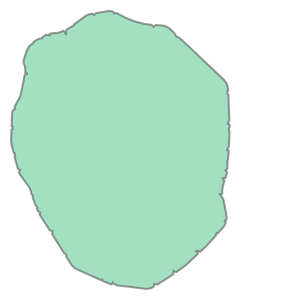

In [33]:
poly_mkad_utm

In [34]:
print("Долгота начальной точки полигона: {},\nШирота начальной точки полигона: {}".\
      format(poly_mkad_utm.exterior.coords.xy[0][0], poly_mkad_utm.exterior.coords.xy[1][0])
      )

Долгота начальной точки полигона: 427352.9580603221,
Широта начальной точки полигона: 6182202.323988725


In [35]:
# Перевод в UTM
gdf_cafe2buy = gdf_cafe2buy.to_crs(crs_fin)
gdf_cafe_competitors = gdf_cafe_competitors.to_crs(crs_fin)
gdf_metro = gdf_metro.to_crs(crs_fin)

In [36]:
# Построим буфер 600м вокруг кафе
gdf_cafe2buy['geometry_buffer_600'] = gdf_cafe2buy.geometry.buffer(600)

In [37]:
gdf_cafe2buy_metro = gpd.sjoin(gdf_cafe2buy.set_geometry("geometry_buffer_600"), gdf_metro[['geometry', 'NameOfStation']],
                                  how='left',
                                  predicate='contains')

In [38]:
gdf_cafe2buy_metro.head()

,global_id,Caption,geometry,flag_in_mkad,geometry_buffer_600,index_right,NameOfStation
0,637429252,coffee,POINT (409788.528 6199951.058),0,"POLYGON ((410388.528 6199951.058, 410385.639 6...",NaN,NaN
1,878847582,coffee,POINT (406333.183 6180036.272),1,"POLYGON ((406933.183 6180036.272, 406930.294 6...",NaN,NaN
2,878848499,coffee,POINT (392430.268 6150197.354),0,"POLYGON ((393030.268 6150197.354, 393027.379 6...",NaN,NaN
3,930779009,coffee,POINT (407685.742 6183708.264),1,"POLYGON ((408285.742 6183708.264, 408282.853 6...",850.0,ЦСКА
3,930779009,coffee,POINT (407685.742 6183708.264),1,"POLYGON ((408285.742 6183708.264, 408282.853 6...",849.0,ЦСКА


In [39]:
gdf_cafe2buy_metro.shape

(8, 7)

In [40]:
gdf_cafe2buy_metro = gdf_cafe2buy_metro.groupby(['global_id'])['NameOfStation'].\
                                          count().reset_index()

In [41]:
gdf_cafe2buy_metro

,global_id,NameOfStation
0,1026816942,3
1,637429252,0
2,878847582,0
3,878848499,0
4,930779009,2


In [42]:
gdf_cafe2buy_metro.columns

Index(['global_id', 'NameOfStation'], dtype='object')

In [43]:
gdf_cafe2buy.merge(gdf_cafe2buy_metro,
                   on = 'global_id',
                   how = 'left')

,global_id,Caption,geometry,flag_in_mkad,geometry_buffer_600,NameOfStation
0,637429252,coffee,POINT (409788.528 6199951.058),0,"POLYGON ((410388.528 6199951.058, 410385.639 6...",0
1,878847582,coffee,POINT (406333.183 6180036.272),1,"POLYGON ((406933.183 6180036.272, 406930.294 6...",0
2,878848499,coffee,POINT (392430.268 6150197.354),0,"POLYGON ((393030.268 6150197.354, 393027.379 6...",0
3,930779009,coffee,POINT (407685.742 6183708.264),1,"POLYGON ((408285.742 6183708.264, 408282.853 6...",2
4,1026816942,coffee,POINT (422577.02 6174551.882),1,"POLYGON ((423177.02 6174551.882, 423174.131 61...",3


In [44]:
gdf_cafe2buy = gdf_cafe2buy.merge(gdf_cafe2buy_metro, on="global_id")

 8. Построить буферы 100 и 1000 м и сцепить слева с таблицей gdf_cafe_competitors


## 3. Кол-во кафе-конкурентов в радиусе 100 метров

In [45]:
gdf_cafe2buy['geometry_buffer_100'] = gdf_cafe2buy.buffer(100)

In [46]:
gdf_cafe2buy

,global_id,Caption,geometry,flag_in_mkad,geometry_buffer_600,NameOfStation,geometry_buffer_100
0,637429252,coffee,POINT (409788.528 6199951.058),0,"POLYGON ((410388.528 6199951.058, 410385.639 6...",0,"POLYGON ((409888.528 6199951.058, 409888.047 6..."
1,878847582,coffee,POINT (406333.183 6180036.272),1,"POLYGON ((406933.183 6180036.272, 406930.294 6...",0,"POLYGON ((406433.183 6180036.272, 406432.701 6..."
2,878848499,coffee,POINT (392430.268 6150197.354),0,"POLYGON ((393030.268 6150197.354, 393027.379 6...",0,"POLYGON ((392530.268 6150197.354, 392529.786 6..."
3,930779009,coffee,POINT (407685.742 6183708.264),1,"POLYGON ((408285.742 6183708.264, 408282.853 6...",2,"POLYGON ((407785.742 6183708.264, 407785.26 61..."
4,1026816942,coffee,POINT (422577.02 6174551.882),1,"POLYGON ((423177.02 6174551.882, 423174.131 61...",3,"POLYGON ((422677.02 6174551.882, 422676.539 61..."


In [47]:
# Убедимся, что в подсчете числа конкурентов в радиусе 100 м не учитывается кафе для покупки
gdf_cafe_competitors[gdf_cafe_competitors.global_id.isin(gdf_cafe2buy.global_id.values)]

,global_id,Caption,geometry


In [48]:
gdf_cafe_100m_competitors = gpd.sjoin(gdf_cafe2buy.set_geometry('geometry_buffer_100'),gdf_cafe_competitors[['geometry']],
                                      how = 'left',
                                      predicate = 'contains',
                                      lsuffix = 'main',
                                      rsuffix='compet')

In [49]:
gdf_cafe_100m_competitors.head()

,global_id,Caption,geometry,flag_in_mkad,geometry_buffer_600,NameOfStation,geometry_buffer_100,index_compet
0,637429252,coffee,POINT (409788.528 6199951.058),0,"POLYGON ((410388.528 6199951.058, 410385.639 6...",0,"POLYGON ((409888.528 6199951.058, 409888.047 6...",NaN
1,878847582,coffee,POINT (406333.183 6180036.272),1,"POLYGON ((406933.183 6180036.272, 406930.294 6...",0,"POLYGON ((406433.183 6180036.272, 406432.701 6...",3428.0
1,878847582,coffee,POINT (406333.183 6180036.272),1,"POLYGON ((406933.183 6180036.272, 406930.294 6...",0,"POLYGON ((406433.183 6180036.272, 406432.701 6...",3551.0
2,878848499,coffee,POINT (392430.268 6150197.354),0,"POLYGON ((393030.268 6150197.354, 393027.379 6...",0,"POLYGON ((392530.268 6150197.354, 392529.786 6...",NaN
3,930779009,coffee,POINT (407685.742 6183708.264),1,"POLYGON ((408285.742 6183708.264, 408282.853 6...",2,"POLYGON ((407785.742 6183708.264, 407785.26 61...",7265.0


In [50]:
gdf_cafe2buy_100m_compet = gdf_cafe_100m_competitors.groupby('global_id')['index_compet'].nunique().rename('compet_100_count').reset_index()

In [51]:
gdf_cafe2buy_100m_compet

,global_id,compet_100_count
0,1026816942,1
1,637429252,0
2,878847582,2
3,878848499,0
4,930779009,61


In [52]:
gdf_cafe2buy = gdf_cafe2buy.merge(gdf_cafe2buy_100m_compet, on = "global_id", how="left")

## 4. Кол-во кафе-конкурентов в радиусе 1000 метров

In [53]:
gdf_cafe2buy['geometry_buffer_1000'] = gdf_cafe2buy.buffer(1000)

In [54]:
gdf_cafe2buy

,global_id,Caption,geometry,flag_in_mkad,geometry_buffer_600,NameOfStation,geometry_buffer_100,compet_100_count,geometry_buffer_1000
0,637429252,coffee,POINT (409788.528 6199951.058),0,"POLYGON ((410388.528 6199951.058, 410385.639 6...",0,"POLYGON ((409888.528 6199951.058, 409888.047 6...",0,"POLYGON ((410788.528 6199951.058, 410783.713 6..."
1,878847582,coffee,POINT (406333.183 6180036.272),1,"POLYGON ((406933.183 6180036.272, 406930.294 6...",0,"POLYGON ((406433.183 6180036.272, 406432.701 6...",2,"POLYGON ((407333.183 6180036.272, 407328.367 6..."
2,878848499,coffee,POINT (392430.268 6150197.354),0,"POLYGON ((393030.268 6150197.354, 393027.379 6...",0,"POLYGON ((392530.268 6150197.354, 392529.786 6...",0,"POLYGON ((393430.268 6150197.354, 393425.452 6..."
3,930779009,coffee,POINT (407685.742 6183708.264),1,"POLYGON ((408285.742 6183708.264, 408282.853 6...",2,"POLYGON ((407785.742 6183708.264, 407785.26 61...",61,"POLYGON ((408685.742 6183708.264, 408680.927 6..."
4,1026816942,coffee,POINT (422577.02 6174551.882),1,"POLYGON ((423177.02 6174551.882, 423174.131 61...",3,"POLYGON ((422677.02 6174551.882, 422676.539 61...",1,"POLYGON ((423577.02 6174551.882, 423572.205 61..."


In [55]:
# Убедимся, что в подсчете числа конкурентов в радиусе 1000 м не учитывается кафе для покупки
gdf_cafe_competitors[gdf_cafe_competitors.global_id.isin(gdf_cafe2buy.global_id.values)]

,global_id,Caption,geometry


In [56]:
gdf_cafe_1000m_competitors = gpd.sjoin(gdf_cafe2buy.set_geometry('geometry_buffer_1000'),gdf_cafe_competitors[['geometry']],
                                      how = 'left',
                                      predicate = 'contains',
                                      lsuffix = 'main',
                                      rsuffix='compet')

In [57]:
gdf_cafe_1000m_competitors.head()

,global_id,Caption,geometry,flag_in_mkad,geometry_buffer_600,NameOfStation,geometry_buffer_100,compet_100_count,geometry_buffer_1000,index_compet
0,637429252,coffee,POINT (409788.528 6199951.058),0,"POLYGON ((410388.528 6199951.058, 410385.639 6...",0,"POLYGON ((409888.528 6199951.058, 409888.047 6...",0,"POLYGON ((410788.528 6199951.058, 410783.713 6...",7281
0,637429252,coffee,POINT (409788.528 6199951.058),0,"POLYGON ((410388.528 6199951.058, 410385.639 6...",0,"POLYGON ((409888.528 6199951.058, 409888.047 6...",0,"POLYGON ((410788.528 6199951.058, 410783.713 6...",5090
0,637429252,coffee,POINT (409788.528 6199951.058),0,"POLYGON ((410388.528 6199951.058, 410385.639 6...",0,"POLYGON ((409888.528 6199951.058, 409888.047 6...",0,"POLYGON ((410788.528 6199951.058, 410783.713 6...",6465
0,637429252,coffee,POINT (409788.528 6199951.058),0,"POLYGON ((410388.528 6199951.058, 410385.639 6...",0,"POLYGON ((409888.528 6199951.058, 409888.047 6...",0,"POLYGON ((410788.528 6199951.058, 410783.713 6...",5089
1,878847582,coffee,POINT (406333.183 6180036.272),1,"POLYGON ((406933.183 6180036.272, 406930.294 6...",0,"POLYGON ((406433.183 6180036.272, 406432.701 6...",2,"POLYGON ((407333.183 6180036.272, 407328.367 6...",1642


In [58]:
gdf_cafe2buy_1000m_compet = gdf_cafe_1000m_competitors.groupby('global_id')['index_compet'].nunique().rename('compet_1000_count').reset_index()

In [59]:
gdf_cafe2buy_1000m_compet

,global_id,compet_1000_count
0,1026816942,31
1,637429252,4
2,878847582,23
3,878848499,10
4,930779009,90


In [60]:
gdf_cafe2buy_full = gdf_cafe2buy.merge(gdf_cafe2buy_1000m_compet, on = "global_id", how="left")

In [61]:
gdf_cafe2buy_full

,global_id,Caption,geometry,flag_in_mkad,geometry_buffer_600,NameOfStation,geometry_buffer_100,compet_100_count,geometry_buffer_1000,compet_1000_count
0,637429252,coffee,POINT (409788.528 6199951.058),0,"POLYGON ((410388.528 6199951.058, 410385.639 6...",0,"POLYGON ((409888.528 6199951.058, 409888.047 6...",0,"POLYGON ((410788.528 6199951.058, 410783.713 6...",4
1,878847582,coffee,POINT (406333.183 6180036.272),1,"POLYGON ((406933.183 6180036.272, 406930.294 6...",0,"POLYGON ((406433.183 6180036.272, 406432.701 6...",2,"POLYGON ((407333.183 6180036.272, 407328.367 6...",23
2,878848499,coffee,POINT (392430.268 6150197.354),0,"POLYGON ((393030.268 6150197.354, 393027.379 6...",0,"POLYGON ((392530.268 6150197.354, 392529.786 6...",0,"POLYGON ((393430.268 6150197.354, 393425.452 6...",10
3,930779009,coffee,POINT (407685.742 6183708.264),1,"POLYGON ((408285.742 6183708.264, 408282.853 6...",2,"POLYGON ((407785.742 6183708.264, 407785.26 61...",61,"POLYGON ((408685.742 6183708.264, 408680.927 6...",90
4,1026816942,coffee,POINT (422577.02 6174551.882),1,"POLYGON ((423177.02 6174551.882, 423174.131 61...",3,"POLYGON ((422677.02 6174551.882, 422676.539 61...",1,"POLYGON ((423577.02 6174551.882, 423572.205 61...",31


In [62]:
gdf_cafe2buy_dash = gdf_cafe2buy_full.select_dtypes(exclude="geometry")

In [63]:
gdf_cafe2buy_dash

,global_id,Caption,flag_in_mkad,NameOfStation,compet_100_count,compet_1000_count
0,637429252,coffee,0,0,0,4
1,878847582,coffee,1,0,2,23
2,878848499,coffee,0,0,0,10
3,930779009,coffee,1,2,61,90
4,1026816942,coffee,1,3,1,31


**Вывод**:
*   Установлено, что в пределах МКАДа находится три точки кафе с global_id = 878847582, 930779009 и 1026816942;
*   В радиусе 600 метров только у двух точек кафе расположены станции метро. Точка с global_id = 930779009 имеет две станции метро (уникальных названий, а не метро), с global_id = 1026816942 – три. Следовательно, здесь больше потенциальных покупателей, а значит эти места привлекательнее;
*   Для точки с global_id = 1026816942 в радиусе 100 метров зафиксировано наименьшее количество конкурентов в выборке — всего 1 объект; в радиусе 1000 метров - 31 объект. В то время как для точки с global_id = 930779009 в радиусе 100 метров зафиксирован 61 объект, а в радиусе 1000 метров - 90 объектов.

Таким образом, в соответствии с предложенными критериями точка кафе с global_id=1026816942 подходит для покупки наилучшим образом.